# Global density constraints in the scattered-voltage basis $V_\mathrm{sca}$

Same as `densityConstraintGlob.ipynb`, but with the optimization variable $x = V_\mathrm{sca} = -Z_0 I$ (formulation of `VscatBound.ipynb`): global power conservation (real and imaginary part, shared projectors) and two general constraints on the inferred material density
$$\rho_i = \frac{Z_s I_i}{u_i}, \qquad u = V - Z_0 I = V + V_\mathrm{sca}, \qquad I = -W V_\mathrm{sca},\quad W = Z_0^{-1}.$$
Multiplying by $|u_i|^2$ gives quadratic constraints:
$$\sum_i w_i \operatorname{Im}\left[Z_s I_i u_i^*\right] = 0 \quad (\operatorname{Im}\rho = 0),\qquad
\sum_i w_i \left(\operatorname{Re}\left[Z_s I_i u_i^*\right] - p\,|u_i|^2\right) = 0 \quad (\operatorname{Re}\rho = p).$$

In [27]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [28]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [29]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Objective in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$ the radiated power $\tfrac12 I^H R_0 I$ takes the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{sca}$, with
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = 0,\qquad c_0 = 0 .$$
The quadratic part is identical to the $V_\mathrm{tot}$ formulation.

In [30]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.750e+04
Objective for full plate in Vsca: 1.010821e+01 W (I basis 1.010821e+01 W)


## Power conservation in the shared projector form

For a complex diagonal projector $P = \operatorname{diag}(p)$ the constraint $\operatorname{Re}\left[I^H P (V + V_\mathrm{sca} - Z_s I)\right] = 0$
holds for any structure. With $I = -W V_\mathrm{sca}$ it reads $\operatorname{Re}\left(-x^H B x + 2x^H s\right) = 0$,
$$B = W^H P (1 + Z_s W),\qquad s = -\tfrac12 W^H P V ,$$
without a constant. Using $\operatorname{Re}(x^H B x) = \operatorname{Re}(x^H B^H x)$, $B^H = (1 + Z_s^* W^H)\, P^*\, W$, this is the shared projector form
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_s^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V,\qquad P' = P^H = \operatorname{diag}(p^*),$$
i.e. the current-basis constraint with $U^H = A_1$ and $I = -A_2 x$ written in $V_\mathrm{sca}$.

The global real ($p = \mathbf 1$) and reactive ($p = -j\mathbf 1$) power constraints are $P' = \mathbf 1$ and $P' = j\mathbf 1$.
For $P' = \mathbf 1$, $\operatorname{Sym}(A_1 A_2) = W^H \operatorname{Re}(Z_\mathrm{tot}) W$ (using $\operatorname{Sym}W = W^H R_0 W$),
the congruent image of the $I$-basis real power constraint.

In [31]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-3.73e-13 (direct -3.72e-13)', '2.64e-12 (direct 2.64e-12)']
random p, random x: shared form 1.126390e+00, direct 1.126390e+00


## Density constraints

dolphindes applies the general constraints to $y = A_2 x = W V_\mathrm{sca} = -I$, $\operatorname{Re}\left(-y^H B y + 2 y^H s\right) + c = 0$. They are therefore the current-basis constraints of `densityConstraintGlob.ipynb` with the sign of the linear term flipped ($I = -y$):

Imaginary part, $\sum_i w_i \operatorname{Im}\left[Z_s I_i u_i^*\right]$:
$$B_\mathrm{Im} = -\operatorname{Sym}\left(j Z_s Z_0^H D_w\right),\qquad s_\mathrm{Im} = -\tfrac{j}{2} Z_s^* D_w V .$$
Real part, $\sum_i w_i \left(\operatorname{Re}\left[Z_s I_i u_i^*\right] - p|u_i|^2\right)$:
$$B_\mathrm{Re} = \operatorname{Sym}\left(Z_s Z_0^H D_w\right) + p\, Z_0^H D_w Z_0,\qquad
s_\mathrm{Re} = -\tfrac{1}{2} Z_s^* D_w V - p\, Z_0^H D_w V,\qquad c_\mathrm{Re} = -p\, V^H D_w V .$$
Both are normalized by $\|B\|_2$ and checked against the direct evaluation with $u = V + V_\mathrm{sca}$. The uniform design $\rho_i = p$, $(Z_s/p + Z_0) I = V$, satisfies both.

In [32]:
pDens = 0.99             # target real part of the material density
wDens = np.ones(Ndes)   # weights of the density sums
Dw = np.diag(wDens)

# imaginary part:  sum_i w_i Im[Zs I_i u_i^*] = 0,  in y = A2 x = -I
BdensIm = -Msym(1j*Zs * Z0.conj().T @ Dw)
sDensIm = -1j*np.conj(Zs) * wDens * Vinc / 2
cDensIm = 0.0
scIm = np.linalg.norm(BdensIm, 2)
BdensIm, sDensIm, cDensIm = BdensIm/scIm, sDensIm/scIm, cDensIm/scIm

# real part:  sum_i w_i (Re[Zs I_i u_i^*] - p |u_i|^2) = 0,  in y = A2 x = -I
BdensRe = Msym(Zs * Z0.conj().T @ Dw) + pDens * Z0.conj().T @ Dw @ Z0
sDensRe = -(np.conj(Zs) * wDens * Vinc / 2 + pDens * Z0.conj().T @ (wDens * Vinc))
cDensRe = -pDens * np.real(Vinc.conj() @ (wDens * Vinc))
scRe = np.linalg.norm(BdensRe, 2)
BdensRe, sDensRe, cDensRe = BdensRe/scRe, sDensRe/scRe, cDensRe/scRe

def genRes(Vsca, B, s, c):
    # Re(-y^H B y + 2 y^H s) + c with y = A2 Vsca, as dolphindes evaluates general constraints
    y = A2 @ Vsca
    return np.real(-y.conj() @ B @ y + 2*y.conj() @ s) + c

def directDens(Vsca):
    # direct evaluation of both density constraints (same normalization)
    I, u = VtoI(Vsca), Vinc + Vsca
    q = Zs*I*np.conj(u)
    return np.sum(wDens*np.imag(q))/scIm, np.sum(wDens*(np.real(q) - pDens*np.abs(u)**2))/scRe

def complexDensity(Vsca):
    # inferred complex material density rho = Zs I / (V + Vsca) (Cholesky space)
    return Zs*VtoI(Vsca)/(Vinc + Vsca)

Iunif = np.linalg.solve(Zs/pDens*np.eye(Ndes) + Z0, Vinc)   # uniform design rho = p
Vunif = -Z0 @ Iunif
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
for name, x in [("full plate", Vfull), (f"uniform rho = {pDens}", Vunif), ("random x", xRand)]:
    dIm, dRe = directDens(x)
    print(f"{name}: Im density residual {genRes(x, BdensIm, sDensIm, cDensIm):.6e} (direct {dIm:.6e}), "
          f"Re density residual {genRes(x, BdensRe, sDensRe, cDensRe):.6e} (direct {dRe:.6e}), "
          f"power conservation residuals {[f'{projRes(x, Pp):.2e}' for Pp in Plist]}")

full plate: Im density residual -1.028908e-15 (direct -1.445471e-16), Re density residual 1.305630e-13 (direct 1.281741e-13), power conservation residuals ['-3.73e-13', '2.64e-12']
uniform rho = 0.99: Im density residual -6.229826e-16 (direct 2.429531e-16), Re density residual 2.405263e-15 (direct 1.743440e-22), power conservation residuals ['2.18e-03', '2.18e-03']
random x: Im density residual -4.938348e-05 (direct -4.938348e-05), Re density residual -9.892290e-07 (direct -9.892290e-07), power conservation residuals ['-1.88e+00', '-8.54e-01']


## Reference bounds: power conservation only, and power conservation + zero imaginary density

In [33]:
opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

def reportBound(name, Q):
    x = Q.current_xstar
    print(f"{name}: bound {Q.current_dual:.6e} W, P(x*) {evalObj(x):.6e} W, Lagrange multipliers {Q.current_lags}")
    print(f"    min eigenvalue of A {np.min(np.linalg.eigvalsh(Msym(Q._get_total_A(Q.current_lags)))):.3e}, residuals at x*: power",
          [f"{projRes(x, Pp):.2e}" for Pp in Plist],
          f"Im density {genRes(x, BdensIm, sDensIm, cDensIm):.2e}, Re density {genRes(x, BdensRe, sDensRe, cDensRe):.2e}")

# global power conservation only
QCQP_P = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=0)
QCQP_P.solve_current_dual_problem(method='newton', init_lags=np.array([1., 0.]), opt_params=opt_params)
reportBound("power conservation", QCQP_P)

# global power conservation + zero weighted imaginary density
QCQP_PIm = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2,
                               B_j=[BdensIm], s_2j=[sDensIm], c_2j=[cDensIm], verbose=0)
QCQP_PIm.solve_current_dual_problem(method='newton', init_lags=np.array([1., 0., 0.]), opt_params=opt_params)
reportBound("power conservation + Im density", QCQP_PIm)
print(f"full plate {Pfull:.6e} W")

power conservation: bound 1.012093e+01 W, P(x*) 1.012093e+01 W, Lagrange multipliers [ 0.98806808 -0.03777126]
    min eigenvalue of A 1.813e-06, residuals at x*: power ['4.99e-09', '6.68e-08'] Im density -2.97e-12, Re density -6.00e-08
power conservation + Im density: bound 1.012093e+01 W, P(x*) 1.012093e+01 W, Lagrange multipliers [ 0.98769667 -0.03739945  7.74814805]
    min eigenvalue of A 1.813e-06, residuals at x*: power ['6.99e-06', '2.37e-06'] Im density 2.22e-10, Re density -6.00e-08
full plate 1.010821e+01 W


## Dual problem: power conservation + Im and Re density

In [34]:
QCQP = DenseSharedProjQCQP(
    Obj, obj, obj0,
    A1, s1,
    Plist, A2=A2,
    B_j=[BdensIm, BdensRe], s_2j=[sDensIm, sDensRe], c_2j=[cDensIm, cDensRe],
    verbose=1,
)

# lambda = 1 on the real power constraint makes A dual feasible
lags_init = np.zeros(QCQP.get_number_constraints())
lags_init[0] = 1
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 4 A matrices and Fs vectors.
initial lags dual feasible: True
bound: 1.012093e+01 W, time: 0.05s, Lagrange multipliers: [ 0.98800693 -0.03771015  1.27468209 -0.02143182]


In [35]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(VtoI(Vstar)):.6e} W), "
      f"full plate {Pfull:.6e} W, uniform rho = {pDens}: {evalObjI(Iunif):.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist],
      f"Im {genRes(Vstar, BdensIm, sDensIm, cDensIm):.2e}, Re {genRes(Vstar, BdensRe, sDensRe, cDensRe):.2e}")

minimum eigenvalue of A: 1.813e-06
dual bound 1.012093e+01 W, P(x*) 1.012093e+01 W (I basis 1.012093e+01 W), full plate 1.010821e+01 W, uniform rho = 0.99: 1.010610e+01 W
constraint residuals at x*: ['1.10e-08', '-1.54e-06'] Im 7.42e-11, Re -6.00e-08


## GCD refinement

Generalized constraint descent on the projector constraints (`gcd.run_gcd`); the two density constraints stay as general constraints. Warm started from the global solution. `ortho_metric='euclidean'` converged much faster than the default `'hilbert_schmidt'` in `densityConstraintsImag.ipynb`. The projectors are generated in the $V_\mathrm{sca}$ basis as in `VscatBound.ipynb`.

In [36]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

gcd_QCQP = copy.deepcopy(QCQP)

gcd_opt_params = OptimizationHyperparameters(
    opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0
)

gcd_params = GCDHyperparameters(
    max_proj_cstrt_num=30,
    max_gcd_iter_num=50,
    gcd_iter_period=5,
    gcd_tol=1e-3,
    orthonormalize=True,
    ortho_metric='euclidean',
    method='newton',
    opt_params=gcd_opt_params,
)

t = time.time()
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f"gcd optimization took time {time.time()-t:.1f}s")

Precomputed 4 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             10.12093275129962.
min eigenvalue: 1.813240e-06
At GCD iteration #2, best dual bound found is             10.11347457256311.
min eigenvalue: 1.634936e-06
At GCD iteration #3, best dual bound found is             10.113454659884276.
min eigenvalue: 1.635066e-06
At GCD iteration #4, best dual bound found is             10.10822134683091.
min eigenvalue: 5.004686e-02
At GCD iteration #5, best dual bound found is             10.108218674283126.
min eigenvalue: 5.004686e-02
At GCD iteration #6, best dual bound found is             10.10821766553834.
min eigenvalue: 5.004684e-02
At GCD iteration #7, best dual bound found is             10.10821720402253.
min eigenvalue: 5.004684e-02
At GCD iteration #8, best dual bound found is             10.108216963807497.
min eigenvalue: 5.004682e-02
At GCD iteration #9, best dual bound found is             10.108216827273237.
min eigenvalue: 5.004681e-02
A

In [37]:
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = gcd_QCQP.current_xstar
print(f"GCD dual bound {gcd_QCQP.current_dual:.6e} W (global {QCQP.current_dual:.6e} W), P(x*) {evalObj(Vstar):.6e} W, full plate {Pfull:.6e} W")
print(f"{gcd_QCQP.n_proj_constr} projector constraints, density multipliers {lags[gcd_QCQP.n_proj_constr:]}")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist],
      f"Im {genRes(Vstar, BdensIm, sDensIm, cDensIm):.2e}, Re {genRes(Vstar, BdensRe, sDensRe, cDensRe):.2e}")

minimum eigenvalue of A: 5.005e-02
GCD dual bound 1.010822e+01 W (global 1.012093e+01 W), P(x*) 1.010824e+01 W, full plate 1.010821e+01 W
20 projector constraints, density multipliers [-79429419.03690283  21738944.58226773]
constraint residuals at x*: ['-1.61e-05', '4.90e-04'] Im -2.43e-08, Re 9.97e-14


## Inferred complex material density

$\rho = Z_s I / (V + V_\mathrm{sca})$, $I = -W V_\mathrm{sca}$, at the optimal scattered voltages of the global and the GCD bound. Realized objective of the inferred designs: $\operatorname{Re}\rho$ clipped to $[0, 1]$ and binarized at $0.5$, solving $(Z_s + D_\rho Z_0) I = D_\rho V$.

global bound: Re rho in [-0.264, 1.228], Im rho in [-0.178, 0.710], mean Re rho 0.005, ||Im rho||/||rho|| 5.454e-01
    realized objective: clipped 9.511795e-04 W, binary 2.454568e-11 W (2/195 filled)
GCD bound: Re rho in [0.280, 1.099], Im rho in [-0.196, 0.024], mean Re rho 0.963, ||Im rho||/||rho|| 4.936e-02
    realized objective: clipped 1.010752e+01 W, binary 7.284484e+00 W (187/195 filled)
full plate 1.010821e+01 W, uniform rho = 0.99: 1.010610e+01 W


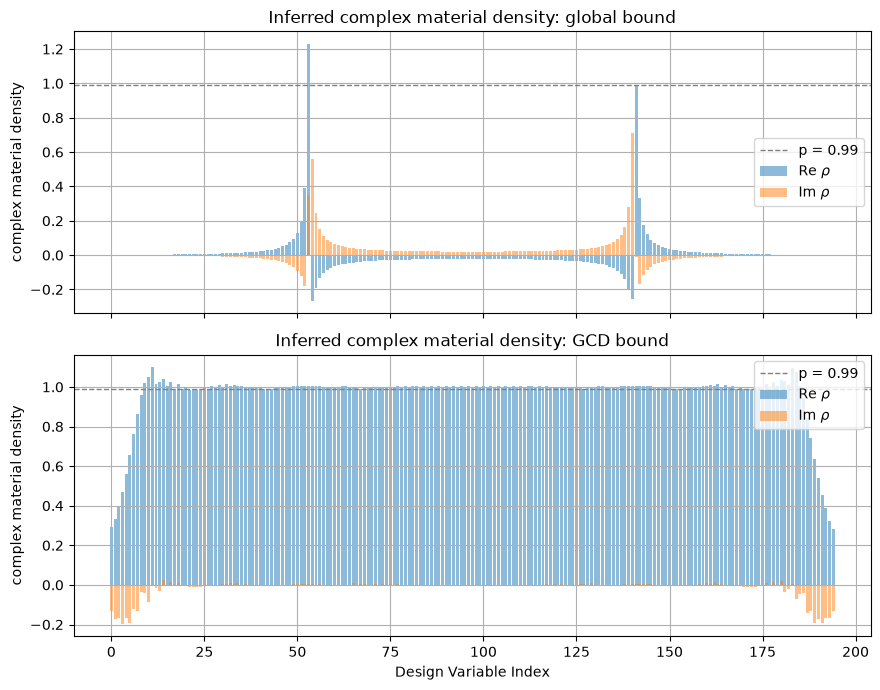

In [38]:
import matplotlib.pyplot as plt

def realizedObj(dens):
    S = np.diag(dens.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rhoGlob = complexDensity(QCQP.current_xstar)
rhoGCD = complexDensity(gcd_QCQP.current_xstar)
cases = [("global bound", rhoGlob), ("GCD bound", rhoGCD)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], "
          f"mean Re rho {rho.real.mean():.3f}, ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")
    print(f"    realized objective: clipped {realizedObj(np.clip(rho.real, 0, 1)):.6e} W, "
          f"binary {realizedObj((rho.real > 0.5).astype(float)):.6e} W ({np.sum(rho.real > 0.5)}/{Ndes} filled)")
print(f"full plate {Pfull:.6e} W, uniform rho = {pDens}: {evalObjI(Iunif):.6e} W")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.axhline(pDens, ls='--', c='gray', lw=1, label=f'p = {pDens}')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Rounding

Threshold rounding of the GCD density, $\rho^\mathrm{bin}_i = [\operatorname{Re}\rho_i > t]$, swept over the distinct values of $\operatorname{Re}\rho$ (every distinct binary design reachable by thresholding), each evaluated with the full-wave solve $(Z_s + D_\rho Z_0) I = D_\rho V$.

best threshold 0.2801: 1.010821e+01 W, fill 1.000 (195/195)
threshold 0.5: 7.284484e+00 W, fill 0.959
GCD bound 1.010822e+01 W, full plate 1.010821e+01 W, clipped design 1.010752e+01 W
best binary / GCD bound = 1.000000
density constraint residuals of the best binary design: Im -1.03e-15, Re 1.31e-13, power conservation ['-3.73e-13', '2.64e-12']


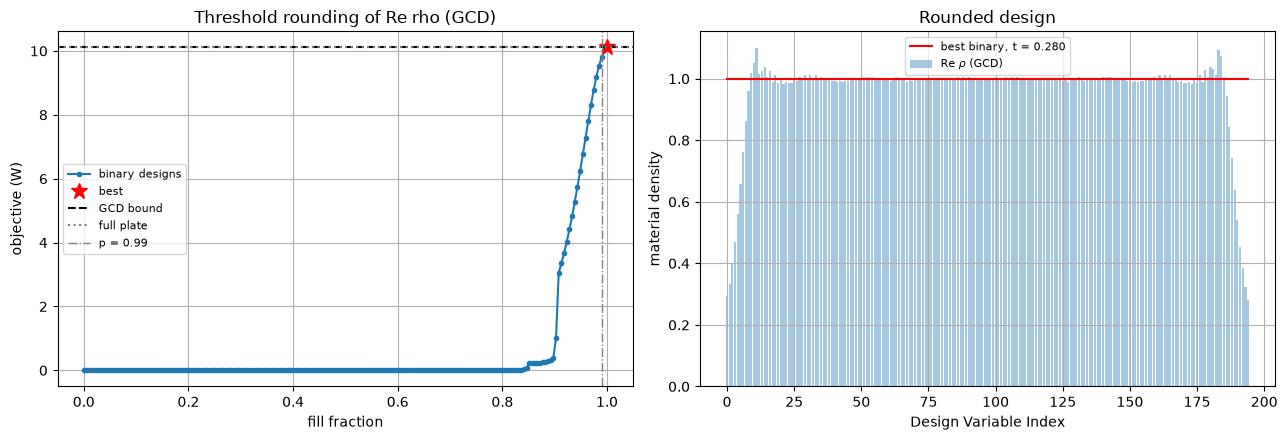

In [39]:
rhoRe = np.real(rhoGCD)
# one threshold between each pair of consecutive sorted values (+ below min / above max)
vals = np.sort(np.unique(rhoRe))
ths = np.concatenate([[vals[0] - 1e-6], 0.5*(vals[1:] + vals[:-1]), [vals[-1] + 1e-6]])
designs = [(rhoRe > t).astype(float) for t in ths]
Pbin = np.array([realizedObj(d) for d in designs])
fill = np.array([d.mean() for d in designs])

ib = int(np.argmax(Pbin))
best = designs[ib]
Ibest = np.linalg.solve(Zs*np.eye(Ndes) + np.diag(best.astype(complex)) @ Z0, best*Vinc)
print(f"best threshold {ths[ib]:.4f}: {Pbin[ib]:.6e} W, fill {fill[ib]:.3f} ({int(best.sum())}/{Ndes})")
print(f"threshold 0.5: {realizedObj((rhoRe > 0.5).astype(float)):.6e} W, fill {np.mean(rhoRe > 0.5):.3f}")
print(f"GCD bound {gcd_QCQP.current_dual:.6e} W, full plate {Pfull:.6e} W, clipped design {realizedObj(np.clip(rhoRe, 0, 1)):.6e} W")
print(f"best binary / GCD bound = {Pbin[ib]/gcd_QCQP.current_dual:.6f}")
Vbest = -Z0 @ Ibest
print(f"density constraint residuals of the best binary design: Im {genRes(Vbest, BdensIm, sDensIm, cDensIm):.2e}, "
      f"Re {genRes(Vbest, BdensRe, sDensRe, cDensRe):.2e}, power conservation {[f'{projRes(Vbest, Pp):.2e}' for Pp in Plist]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(fill, Pbin, 'o-', ms=3, label='binary designs')
ax.plot(fill[ib], Pbin[ib], 'r*', ms=12, label='best')
ax.axhline(gcd_QCQP.current_dual, ls='--', c='k', label='GCD bound')
ax.axhline(Pfull, ls=':', c='gray', label='full plate')
ax.axvline(pDens, ls='-.', c='gray', lw=1, label=f'p = {pDens}')
ax.set_xlabel('fill fraction'); ax.set_ylabel('objective (W)'); ax.set_title('Threshold rounding of Re rho (GCD)')
ax.grid(True); ax.legend(fontsize=8)
ax = axes[1]
ax.bar(np.arange(Ndes), rhoRe, alpha=0.4, label=r'Re $\rho$ (GCD)')
ax.step(np.arange(Ndes), best, where='mid', c='r', label=f'best binary, t = {ths[ib]:.3f}')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel('material density'); ax.set_title('Rounded design')
ax.grid(True); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()